# Data Preparation Section

This notebook documents how raw pull request review data was transformed into a clean, structured dataset suitable for training and evaluating an automated code reviewer.

The actual data cleaning and preprocessing logic lives in dedicated Python modules under `src/ai_code_reviewer/`. This notebook does not reimplement that logic; instead, it explains the design decisions, shows summary statistics, and illustrates the resulting data with selected examples.

In [1]:
import sys, pathlib

PROJECT_ROOT = pathlib.Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 20)

## 1. Raw Data Source

The raw data originates from **GH Archive**, a public dataset that records every public event on GitHub. We focus on `PullRequestReviewCommentEvent` records — events emitted whenever a reviewer leaves a line-level comment on a pull request.

**Unit of analysis.** Each sample in our dataset corresponds to a single *changed Python file* within a pull request. A single PR may produce multiple samples if several files were modified.

For every sample the raw data provides:

| Field                   | Description                                                                           |
|-------------------------|---------------------------------------------------------------------------------------|
| `repo`                  | Repository name (`owner/name`)                                                        |
| `repo_star_count`       | Number of stars the repository has at the time of the event                           |
| `pr_number`             | Pull request number                                                                   |
| `pr_title`              | Title of the pull request                                                             |
| `pr_body`               | Description/body of the pull request                                                  |
| `commit_sha`            | SHA of the commit corresponding to the changed file                                   |
| `path`                  | Path of the changed file relative to the repo root                                    |
| `content`               | Complete content of the changed file after the PR is applied                          |
| `patched_content`       | Full annotated diff of the file (`+`/`-`/` ` interleaved unified diff)                |
| `outgoing_dependencies` | Source code of files imported by the changed file                                     |
| `incoming_dependencies` | Source code of files that import from the changed file                                |
| `metadata_files`        | Repository metadata files (README, CONTRIBUTING, setup.py, etc.)                      |
| `file_tree`             | Tree-shaped listing of the entire repository                                          |
| `comments`              | Human review comments anchored to specific line ranges                                |

In [2]:
RAW_PATH = PROJECT_ROOT / "cleaned_2.parquet"
df_raw = pd.read_parquet(RAW_PATH)

print(f"Total samples: {len(df_raw):,}")
print(f"Unique repositories: {df_raw['repo'].nunique():,}")
print(f"Unique pull requests: {df_raw.groupby(['repo', 'pr_number']).ngroups:,}")
print(f"\nColumns: {list(df_raw.columns)}")
df_raw.head(2)

Total samples: 6,011
Unique repositories: 921
Unique pull requests: 1,326

Columns: ['repo', 'pr_number', 'pr_title', 'pr_body', 'repo_star_count', 'commit_sha', 'path', 'patched_content', 'outgoing_dependencies', 'incoming_dependencies', 'metadata_files', 'file_tree', 'comments', 'has_blocking_issues', 'comment_categories', 'llm_raw_response']


,repo,pr_number,pr_title,pr_body,repo_star_count,commit_sha,path,patched_content,outgoing_dependencies,incoming_dependencies,metadata_files,file_tree,comments,has_blocking_issues,comment_categories,llm_raw_response
0,pandas-dev/pandas,42964,ENH: conditional merge - initial concept,"- [ ] closes #8962\r\n- [ ] tests added / passed\r\n- [ ] Ensure all linting tests pass, see [here](https://pandas.p...",48468,16a6fbecd0c227fbab9b7cb68430ce4a7ee69f46,pandas/core/reshape/merge.py,"""""""\nSQL-style merge routines\n""""""\nfrom __future__ import annotations\n\nimport copy\nimport datetime\nfrom functoo...","[{'content': 'from __future__ import annotations from datetime import ( datetime, timedelta, tzinfo, ) ...","[{'content': '"""""" DataFrame --------- An efficient 2D container for potentially mixed-type time series or other labe...","[{'content': '<div align=""center""> <img src=""https://pandas.pydata.org/static/img/pandas.svg""><br> </div> -------...",pandas/\n├── .circleci/\n│ └── config.yml\n├── .github/\n│ ├── actions/\n│ │ ├── build_pandas/\n│ │ │ ...,"[{'annotated_end_line': 1464.0, 'annotated_start_line': 1464.0, 'body': 'This implicit chunking probably needs to be...",,Too long (limit = 30000 tokens),Too long (limit = 30000 tokens)
1,pandas-dev/pandas,42964,ENH: conditional merge - initial concept,"- [ ] closes #8962\r\n- [ ] tests added / passed\r\n- [ ] Ensure all linting tests pass, see [here](https://pandas.p...",48468,16a6fbecd0c227fbab9b7cb68430ce4a7ee69f46,pandas/tests/reshape/merge/test_merge_conditional.py,+import pytest\n+\n+from pandas import DataFrame\n+import pandas._testing as tm\n+import pandas.core.reshape.merge a...,[{'content': 'from __future__ import annotations import collections from datetime import datetime from decimal impo...,[],"[{'content': '<div align=""center""> <img src=""https://pandas.pydata.org/static/img/pandas.svg""><br> </div> -------...",pandas/\n├── .circleci/\n│ └── config.yml\n├── .github/\n│ ├── actions/\n│ │ ├── build_pandas/\n│ │ │ ...,"[{'annotated_end_line': 62.0, 'annotated_start_line': 62.0, 'body': 'Can you add tests (separate) for all the other ...",,"['best_practice', 'style']",0: best_practice\n1: style


## 2. Initial Preprocessing

The raw GitHub event stream was converted into file-level samples through the following pipeline (implemented in `src/ai_code_reviewer/dataset/`):

1. **Ingestion.** Hourly GH Archive JSON dumps are fetched and filtered to keep only `PullRequestReviewCommentEvent` records with English text bodies and Python file paths.

2. **Enrichment.** For each pull request, the GitHub REST API provides the full patch (via the compare endpoint) and the base file content (via the repository zipball). The GitHub GraphQL API is used to fetch review thread resolution status.

3. **Annotated diff construction.** The raw unified diff is combined with the base file to produce a full-file annotated view where every line is prefixed with `+` (added), `-` (removed), or a space (unchanged). Human comment line numbers are remapped to this annotated view.

4. **No-comment file augmentation.** Changed Python files that received no review comments are included as negative examples.

5. **Filtering decisions:**
   - Only `.py` files are retained.
   - Comments on the left side of the diff (outdated code) and reply comments are excluded.
   - PRs that fail enrichment (missing base commit, API errors) are dropped entirely.

**Why file-level?** A code reviewer operates at the level of individual files: the model receives a single changed file along with its context and must decide whether to flag an issue. This matches real-world review workflows.

In [3]:
import json

def count_comments(raw):
    """Count the number of review comments attached to a sample."""
    if raw is None or (isinstance(raw, float) and pd.isna(raw)):
        return 0
    if isinstance(raw, str):
        try:
            return len(json.loads(raw))
        except (json.JSONDecodeError, TypeError):
            return 0
    try:
        return len(list(raw))
    except TypeError:
        return 0

df_raw["n_comments"] = df_raw["comments"].apply(count_comments)

n_with = (df_raw["n_comments"] > 0).sum()
n_without = (df_raw["n_comments"] == 0).sum()
print(f"Samples with comments:    {n_with:,}")
print(f"Samples without comments: {n_without:,}")
print(f"Comment count distribution:")
df_raw["n_comments"].describe()

Samples with comments:    3,521
Samples without comments: 2,490
Comment count distribution:


count    6011.000000
mean        1.452171
std         2.252194
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max        30.000000
Name: n_comments, dtype: float64

Approximately 3,500 files contain review comments, while around 2,500 do not. The majority of files have between one and two comments, with a maximum observed count of 30 comments per file.

## 3. LLM-based Filtering: Dataset Construction

### Motivation

Human review comments are inherently noisy. Not every comment indicates a bug or a meaningful code issue — reviewers also leave stylistic suggestions, questions, compliments, and nitpicks. Treating all commented files as positive examples of "buggy code" would severely degrade label quality.

Similarly, files that received no comments are not guaranteed to be clean — a reviewer may have simply missed an issue, or the file may not have been reviewed at all.

To address both problems, we employed an **LLM-as-a-judge** pipeline that processes every sample and produces structured labels.

### Classification Taxonomy

To define the taxonomy in a data-driven way rather than relying on intuition, we first sampled approximately **500 human review comments** from the raw dataset and submitted them to a DeepSeek-v3.2 model with an open-ended prompt asking it to identify recurring themes and group them into coherent clusters. After several iterations of refining the clusters in dialogue with the model, we converged on a nine-category taxonomy that balances granularity with practical utility:

| Category | Description |
|---|---|
| `blocking_issue` | Correctness bugs, security vulnerabilities, data-loss risks, crashes, race conditions |
| `performance` | Efficiency concerns, unnecessary allocations, algorithmic complexity |
| `best_practice` | Design patterns, idiomatic code, architectural suggestions, error-handling improvements |
| `style` | Formatting, naming conventions, import ordering, whitespace |
| `documentation` | Missing or incorrect docstrings, comments, type hints |
| `question` | Reviewer asking for clarification or explanation |
| `nitpick` | Minor optional observations that do not affect correctness or style |
| `praise` | Positive feedback, approval, compliments |
| `other` | Does not fit any category above |

For files **without** comments, the judge answers a binary question: does this file contain a blocking issue? (`true` / `false`). Only files validated as `false` are used as clean negative examples.

### What Goes Into the Judge Prompt

To make a well-informed classification decision, the LLM judge needs sufficient context about the code change. During the **Data Understanding** stage we analyzed the raw features and made a series of deliberate decisions about what to include in the prompt and how to compress it. Each component is described below.

#### Repository metadata

The raw dataset contains a `metadata_files` column with full contents of files like `README.md`, `CONTRIBUTING.md`, `setup.py`, and other configuration files. These files provide the judge with a high-level understanding of the project — its purpose, coding standards, and technology stack.

However, READMEs alone can easily exceed 10,000 characters, which would consume a disproportionate share of the context window. Instead of summarizing them with another LLM (which would introduce cost, latency, and non-determinism), we apply **deterministic heuristic compression**:

- `README.md` is truncated to **400 characters** (enough for the project title and a short description).
- `CONTRIBUTING.md` is truncated to **400 characters** (enough to capture coding conventions).
- `setup.py` is parsed with a regex to extract only the project name, version, and install dependencies, capped at **500 characters**.
- The total metadata budget is hard-capped at **4000 characters**.
- Files are prioritized in order: README → CONTRIBUTING → dependency manifests → setup.py.

#### Pull request metadata

The PR title is included verbatim, and the PR body (description) is stripped of HTML tags and truncated to **500 characters**. This gives the judge a brief summary of the author's intent without spending tokens on long checklists or template boilerplate that many PRs contain.

#### Repository file tree

The raw `file_tree` column contains a complete tree listing of the repository, which in the median case consumes roughly 5,000 tokens — far too much for a secondary context signal. We truncate it to **2 levels of depth** (root and its immediate children). Additionally, children of **dot-directories** like `.github/`, `.circleci/`, and `.vscode/` are skipped entirely, since their CI/CD configuration files are rarely relevant to the substance of a code review (among Python-files).

#### Changed file (patched content)

The core of the prompt is the annotated diff of the changed file: every line is prefixed with `+` (added), `-` (removed), or a space (unchanged context). Line numbers are preserved so that the judge can reference specific locations.

Since many files include large sections of unchanged code that are included only for context, we apply several **context-length reduction techniques** — all designed to preserve the semantically important parts while removing redundancy:

1. **Unchanged function bodies are collapsed.** If a function or method definition (`def` / `async def`) has no `+` or `-` lines within its body, the entire body is replaced with a `[function body is hidden]` placeholder. The function signature is preserved so the judge can still see the API surface.

2. **Long docstrings are stripped.** Multi-line triple-quoted strings exceeding **3 lines** are replaced with `[docstring hidden]`. This applies to both standalone docstrings and those embedded in assignments or dict values. The opening and closing quote lines are preserved; only the interior content is removed.

3. **Long comment blocks are collapsed.** Consecutive runs of `#` comment lines exceeding **3 lines** are collapsed to the first 3 lines plus a summary marker `# ... [N comment lines hidden]`.

4. **Excessive blank lines are collapsed.** Runs of more than **2** consecutive blank lines are reduced to 2.

These decisions were made during the Data Understanding phase after inspecting real examples where unchanged boilerplate (auto-generated docstrings, license headers, long comment blocks) dominated the token budget and drowned out the actual code changes.

#### Incoming and outgoing dependencies

Understanding the broader context of a code change often requires knowing what other files interact with it:

- **Outgoing dependencies** are files imported by the changed file (e.g., if the changed file has `from utils import helper`, then `utils.py` is an outgoing dependency).
- **Incoming dependencies** are files that import from the changed file (e.g., if another module does `from changed import some_class`, that module is an incoming dependency).

Including all dependencies would be impractical — popular utility modules can have dozens of importers. We select the **top 5** most relevant files for each direction using a heuristic retriever that filters out boilerplate files (`__init__.py`, `setup.py`, `conftest.py`, `__version__.py`) which rarely contain meaningful context.

The same docstring, comment, and blank-line compression techniques described above are applied to dependency file contents before they are included in the prompt.

### Two Prompt Variants

The pipeline uses two different prompts depending on whether the file has human review comments.

#### Classification prompt (files with comments)

When a file has one or more human review comments, the goal is to classify each comment into one of the nine categories defined in Section 3.2. In addition to all the context described above, the prompt includes the **original review comments** appended at the end. Each comment is formatted with its index and the line range it refers to (e.g., `[Comment 0] Lines 42-45: ...`), so the judge can cross-reference each comment with the corresponding code in the patch. The expected output is one line per comment in the format `<index>: <category>`.

#### Validation prompt (files without comments)

When a file has no human review comments, it is a candidate for becoming a clean negative example. However, the absence of comments does not guarantee the absence of bugs — a reviewer may have overlooked an issue, or the file may not have been reviewed carefully. To filter out such cases, the judge receives the same code context (metadata, tree, patch, dependencies) and is asked a single binary question: does this file contain a blocking issue? The expected output is a single word: `true` or `false`. Only files validated as `false` are kept as clean negatives.

This two-prompt design is important: it ensures that both positive and negative labels in the final dataset are actively validated rather than assumed.

### Infrastructure and Reliability

The pipeline is implemented in `src/ai_code_reviewer/data_processing/data_cleaning.py` and uses Yandex Cloud Foundation Models (Qwen 3 235B — `qwen3-235b-a22b-fp8/latest`) as the judge LLM, accessed via an OpenAI-compatible API.

Several engineering decisions were made to ensure reliability over long runs:

- **Token limit.** Even after all compression steps, some prompts remain too large. Prompts exceeding an estimated **30,000 tokens** (`len(prompt) / 4`) are skipped and marked as `"Too long"` rather than sent to the API. In practice, over 90% of samples (p90) fit within this budget after the compression techniques described above are applied.
- **Checkpointing.** Results are saved to a JSON checkpoint file every 20 rows, allowing the pipeline to resume from the last saved position after an interruption. The checkpoint file is only deleted after the output file has been successfully written to disk.
- **Raw response storage.** The raw LLM response text is stored alongside the parsed label, enabling post-hoc inspection of ambiguous or failed parses.

In [4]:
CLEANED_PATH = PROJECT_ROOT / "cleaned_2.parquet"

try:
    df_cleaned = pd.read_parquet(CLEANED_PATH)
    print(f"Cleaned dataset: {len(df_cleaned):,} rows")
    print(f"\nColumns: {list(df_cleaned.columns)}")
except FileNotFoundError:
    df_cleaned = None
    print(f"Cleaned dataset not found at {CLEANED_PATH}.")
    print("Run the cleaning pipeline first, then re-execute this cell.")

Cleaned dataset: 6,011 rows

Columns: ['repo', 'pr_number', 'pr_title', 'pr_body', 'repo_star_count', 'commit_sha', 'path', 'patched_content', 'outgoing_dependencies', 'incoming_dependencies', 'metadata_files', 'file_tree', 'comments', 'has_blocking_issues', 'comment_categories', 'llm_raw_response']


In [5]:
if df_cleaned is not None:
    print("=== Validation results (files without comments) ===")
    validation_rows = df_cleaned[df_cleaned["has_blocking_issues"] != ""]
    print(validation_rows["has_blocking_issues"].value_counts())

    print("\n=== Classification results (files with comments) ===")
    classification_rows = df_cleaned[df_cleaned["comment_categories"] != ""]
    print(classification_rows["comment_categories"].value_counts().head(20))

    too_long = df_cleaned[
        df_cleaned["has_blocking_issues"].str.startswith("Too long", na=False)
        | df_cleaned["comment_categories"].str.startswith("Too long", na=False)
    ]
    print(f"\nSkipped (too long): {len(too_long):,}")
else:
    print("TODO: run cleaning pipeline and re-execute")

=== Validation results (files without comments) ===
has_blocking_issues
False                              1897
True                                305
Too long (limit = 30000 tokens)     288
Name: count, dtype: int64

=== Classification results (files with comments) ===
comment_categories
Too long (limit = 30000 tokens)                                         517
['best_practice']                                                       417
['style']                                                               310
['question']                                                            248
['nitpick']                                                             210
['blocking_issue']                                                      115
['documentation']                                                        97
['best_practice', 'best_practice']                                       95
['style', 'style']                                                       92
['best_practice', 'best_p

The table above shows file-level category lists (one list per file). To get a per-comment distribution, we explode each file into individual (comment, category) pairs while preserving all other columns for traceability.

In [6]:
import ast

def _parse_list_column(val):
    """Parse a stringified list like "['a', 'b']" back to a Python list."""
    if isinstance(val, list):
        return val
    if not isinstance(val, str) or not val.startswith("["):
        return []
    try:
        return ast.literal_eval(val)
    except (ValueError, SyntaxError):
        return []

def _parse_comments_col(raw):
    if raw is None or (isinstance(raw, float) and pd.isna(raw)):
        return []
    if isinstance(raw, str):
        try:
            return json.loads(raw)
        except (json.JSONDecodeError, TypeError):
            return []
    try:
        return [x for x in list(raw) if isinstance(x, dict)]
    except TypeError:
        return []

if df_cleaned is not None:
    classified = df_cleaned[
        (df_cleaned["comment_categories"] != "")
        & ~df_cleaned["comment_categories"].str.startswith("Too long", na=True)
    ].copy()

    classified["_cats_list"] = classified["comment_categories"].apply(_parse_list_column)
    classified["_comments_list"] = classified["comments"].apply(_parse_comments_col)

    keep_cols = ["repo", "pr_number", "path", "llm_raw_response"]

    rows = []
    for _, row in classified.iterrows():
        cats = row["_cats_list"]
        comments = row["_comments_list"]
        for i in range(min(len(cats), len(comments))):
            rec = {col: row[col] for col in keep_cols if col in row.index}
            rec["comment_idx"] = i
            rec["category"] = cats[i]
            rec["comment_body"] = comments[i].get("body", "")
            rec["start_line"] = comments[i].get("annotated_start_line")
            rec["end_line"] = comments[i].get("annotated_end_line")
            rows.append(rec)

    df_exploded = pd.DataFrame(rows)
    print(f"Total individual comments: {len(df_exploded):,}\n")
    print(df_exploded["category"].value_counts())
else:
    df_exploded = None
    print("TODO: run cleaning pipeline and re-execute")

Total individual comments: 7,190

category
best_practice     2295
style             1754
question           885
blocking_issue     721
nitpick            682
documentation      632
performance         99
praise              88
other               34
Name: count, dtype: int64


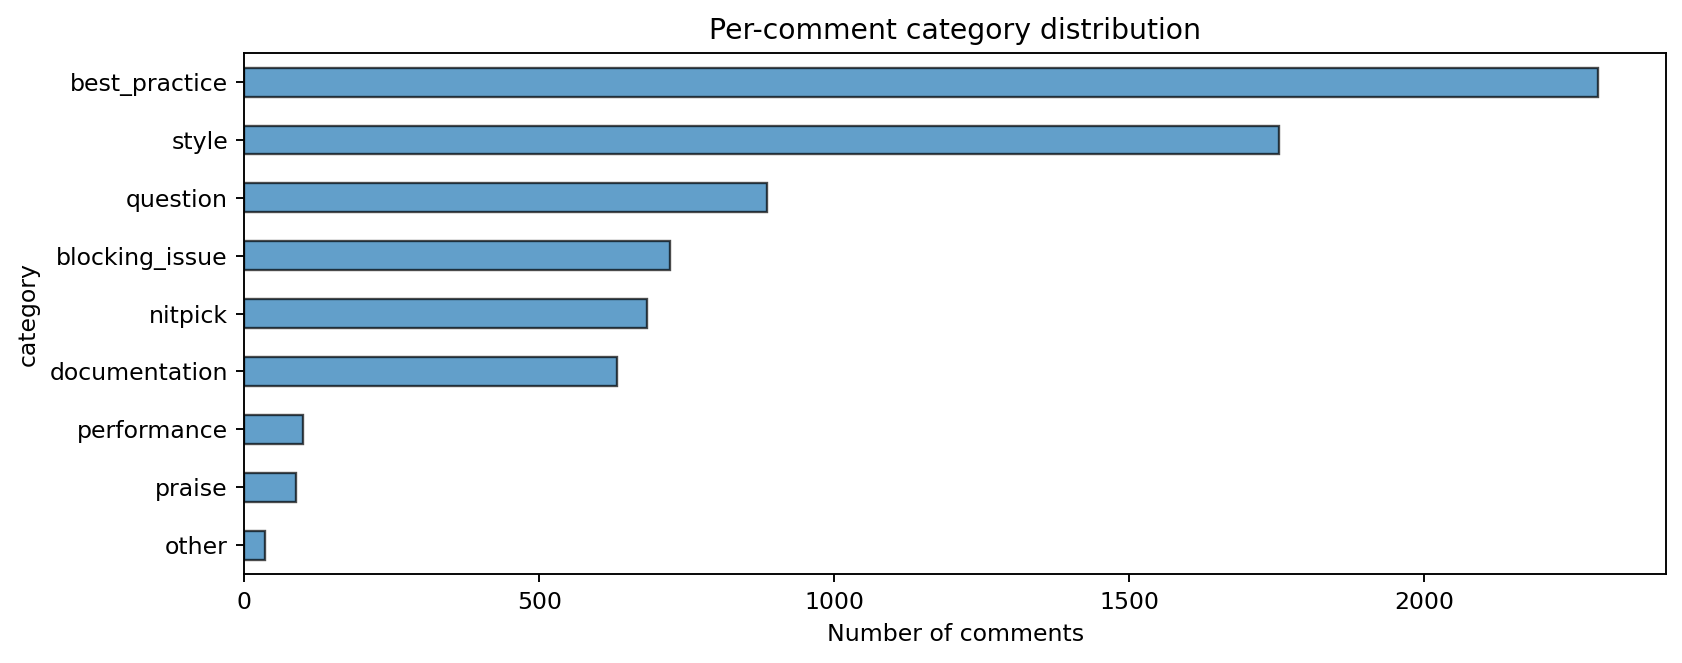

In [7]:
if df_exploded is not None and len(df_exploded) > 0:
    fig, ax = plt.subplots(figsize=(10, 4), dpi=170)
    df_exploded["category"].value_counts().plot.barh(ax=ax, edgecolor="black", alpha=0.7)
    ax.set_xlabel("Number of comments")
    ax.set_title("Per-comment category distribution")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

The distribution reveals a significant class imbalance. `best_practice` and `style` dominate with over 2,000 and 1,700 comments respectively, while `blocking_issue` — the category most relevant for training a bug-detection model — accounts for only around 700 comments. `performance` is even rarer at roughly 100.

This means that if we restrict positive labels to `blocking_issue` alone, the resulting training set will be small. In the following sections we design the composition of the training and validation sets, considering which categories to include as positives, how to balance them against clean negatives, and which samples to exclude.

## 4. Manual Quality Check of Filtering

To verify that the LLM-based classification is reasonable, we manually inspected several examples from each major category. This is a sanity check, not a full annotation effort — its purpose is to confirm that the taxonomy captures meaningful distinctions and that the model's labels broadly align with human judgment.

### No-comment clean negatives

These are files that received no reviewer comments and were validated by the judge as containing no blocking issues.

**Expected:** Routine changes — refactors, documentation updates, test additions — with no obvious bugs.

In [8]:
clean_neg = df_cleaned[df_cleaned["has_blocking_issues"] == "False"]
if len(clean_neg) > 0:
    sample = clean_neg.iloc[0]
    print(f"Repo: {sample['repo']}, PR #{sample['pr_number']}")
    print(f"File: {sample['path']}")
    print(f"\nPatch:\n{sample['patched_content']}")
else:
    print("No clean negative samples found.")

Repo: pandas-dev/pandas, PR #42964
File: pandas/core/indexes/datetimes.py

Patch:
from __future__ import annotations

from datetime import (
    date,
    datetime,
    time,
    timedelta,
    tzinfo,
)
import operator
from typing import (
    TYPE_CHECKING,
    Hashable,
    Literal,
)
import warnings

import numpy as np

from pandas._libs import (
    NaT,
    Period,
    Timestamp,
    index as libindex,
    lib,
)
from pandas._libs.tslibs import (
    Resolution,
    timezones,
    to_offset,
)
from pandas._libs.tslibs.offsets import prefix_mapping
from pandas._typing import (
    Dtype,
    DtypeObj,
    npt,
)
from pandas.util._decorators import (
    cache_readonly,
    doc,
)
from pandas.util._exceptions import find_stack_level

from pandas.core.dtypes.common import (
    DT64NS_DTYPE,
    is_datetime64_dtype,
    is_datetime64tz_dtype,
    is_scalar,
)
from pandas.core.dtypes.missing import is_valid_na_for_dtype

from pandas.core.arrays.datetimes import (
    DatetimeArray,
 

The sample above is a representative clean negative: a well-established pandas module (`pandas/core/indexes/datetimes.py`) where the only change is a standard deprecation warning added to the `union_many` method. No logic is modified, no new edge cases are introduced — the change is purely informational. The LLM judge correctly confirmed that no blocking issue is present.

### Blocking issues

Files where at least one comment was classified as `blocking_issue`.

**Expected:** Comments pointing out genuine bugs, security flaws, or correctness problems.

In [9]:
blocking = df_cleaned[df_cleaned["comment_categories"].str.contains("blocking_issue", na=False)]
if len(blocking) > 0:
    sample = blocking.iloc[0]
    print(f"Repo: {sample['repo']}, PR #{sample['pr_number']}")
    print(f"File: {sample['path']}")
    print(f"Categories: {sample['comment_categories']}")
    print(f"LLM raw response: {sample.get('llm_raw_response', 'N/A')}")
    print("\nComments:")
    for comment in sample.get("comments", []):
        print(f"- {comment.get('body', '')}")
else:
    print("No blocking_issue samples found.")

Repo: daos-stack/daos, PR #7230
File: src/tests/ftest/control/dmg_telemetry_net.py
Categories: ['best_practice', 'best_practice', 'best_practice', 'best_practice', 'blocking_issue', 'blocking_issue']
LLM raw response: 0: best_practice
1: best_practice
2: best_practice
3: best_practice
4: blocking_issue
5: blocking_issue

Comments:
- Without any sorting it seems like `metrics[0]` could possibly not end up being the metric name that is intended to be verified.  I feel it would be better to get all of the `metrics` values - this could even be done with a new `TelemetryUtils.get_engine_net_metrics(self, server_manager)`, negating the need for lines 76-80 - before running mdtest and after stopping a rank.  The two dictionaries could then be compared with something like `TelemetryUtils.verify_metric_values()` - where after reporting all the values/comparisons (for easier triage) a simple status could be returned to indicate if there were any values in the after list that were not greater tha

This file received 6 review comments from a human reviewer, and the LLM judge classified them as 4 × `best_practice` and 2 × `blocking_issue`. Inspecting the raw comments confirms that the classification is reasonable:

- **`blocking_issue` comments** point to real correctness gaps: one notes that the test never verifies whether `mdtest` actually succeeds or fails, and the other flags that certain telemetry metrics are silently ignored instead of being checked. Both identify scenarios where the test could pass while the system under test is broken — exactly the kind of defect we want the model to detect.
- **`best_practice` comments** are valid but softer: avoid hardcoded sleeps, prefer `ThreadManager` over raw `threading.Thread`, use state-detection instead of timers, and encapsulate metric retrieval in a utility method. These improve maintainability and robustness but do not indicate that the code is functionally incorrect today.

The distinction between the two categories is well-calibrated here: `blocking_issue` captures missing verification logic (a true defect), while `best_practice` captures design improvements that would prevent future issues.

### Performance

Files where at least one comment was classified as `performance`.

**Expected:** Comments about efficiency concerns — unnecessary allocations, suboptimal algorithms, redundant computations, or resource mismanagement.

In [10]:
perf = df_exploded[df_exploded["category"] == "performance"]
if len(perf) > 0:
    sample = perf.iloc[0]
    print(f"Repo: {sample['repo']}, PR #{sample['pr_number']}")
    print(f"File: {sample['path']}")
    print(f"Category: {sample['category']}")
    print(f"\nComment body:\n{sample['comment_body'][:500]}")
else:
    print("No performance samples found.")

Repo: PyCQA/pylint, PR #5311
File: pylint/checkers/non_ascii_names.py
Category: performance

Comment body:
Can't we just always pass a list? That would save a `if` + `isinstance` call.


The example above shows a `performance` comment on a pylint checker module. The reviewer suggests replacing a runtime type check (`if` + `isinstance`) with a uniform interface — always passing a list. This is a valid micro-optimization: eliminating a per-call branch simplifies the hot path and avoids the overhead of `isinstance`, which, while small individually, can accumulate in a checker that runs on every name in the analyzed codebase.

The LLM judge classified this as `performance` rather than `best_practice`, which is appropriate: the comment is specifically motivated by reducing runtime overhead, not by code readability or maintainability concerns.

### Best practice

Files where at least one comment was classified as `best_practice`.

**Expected:** Suggestions about design patterns, idiomatic code, architectural improvements, or error-handling practices. These are often valuable but less critical than blocking issues — they suggest how the code *should* be written rather than pointing out a concrete defect.

In [11]:
bp = df_exploded[df_exploded["category"] == "best_practice"]
if len(bp) > 0:
    sample = bp.iloc[0]
    print(f"Repo: {sample['repo']}, PR #{sample['pr_number']}")
    print(f"File: {sample['path']}")
    print(f"Category: {sample['category']}")
    print(f"\nComment body:\n{sample['comment_body'][:500]}")
else:
    print("No best_practice samples found.")

Repo: pandas-dev/pandas, PR #42964
File: pandas/tests/reshape/merge/test_merge_conditional.py
Category: best_practice

Comment body:
Can you add tests (separate) for all the other `ValueError`/`NotImplementedError` you are raising?


The reviewer asks for dedicated test cases covering each `ValueError` and `NotImplementedError` raised in the implementation. This is a textbook `best_practice` comment: the code is not broken — the exceptions are raised correctly — but without explicit tests for these error paths, regressions could go unnoticed in future refactors.

### Style

Files where at least one comment was classified as `style`.

**Expected:** Formatting and naming convention suggestions — import ordering, whitespace, variable naming, code style guide violations. These are cosmetic and do not indicate functional problems.

In [12]:
style = df_exploded[df_exploded["category"] == "style"]
if len(style) > 0:
    sample = style.iloc[0]
    print(f"Repo: {sample['repo']}, PR #{sample['pr_number']}")
    print(f"File: {sample['path']}")
    print(f"Category: {sample['category']}")
    print(f"\nComment body:\n{sample['comment_body'][:500]}")
else:
    print("No style samples found.")

Repo: pandas-dev/pandas, PR #42964
File: pandas/tests/reshape/merge/test_merge_conditional.py
Category: style

Comment body:
`from pandas.core.reshape import merge`


A typical `style` comment: the reviewer suggests changing the import path for the `merge` module to follow the project's conventions (`from pandas.core.reshape import merge` instead of the form used in the PR). This is purely a stylistic preference — the code works correctly either way, but consistent import style across the codebase improves readability and grep-ability.

### Nitpicks

**Expected:** Minor optional observations — trivial naming suggestions, micro-optimizations, or subjective preferences that do not affect correctness.

In [13]:
nitpicks = df_cleaned[df_cleaned["comment_categories"].str.contains("nitpick", na=False)]
if len(nitpicks) > 0:
    sample = nitpicks.iloc[0]
    print(f"Repo: {sample['repo']}, PR #{sample['pr_number']}")
    print(f"File: {sample['path']}")
    print(f"Categories: {sample['comment_categories']}")
    print(f"LLM raw response: {sample.get('llm_raw_response', 'N/A')}")
    # Print all comment bodies if available (works for exploded or nested)
    if "comments" in sample:
        comments = sample["comments"]
        if isinstance(comments, list):
            for i, comment in enumerate(comments):
                body = comment.get("body", str(comment)) if isinstance(comment, dict) else str(comment)
                print(f"Comment {i+1}: {body[:500]}")
        else:
            print(f"Comment: {comments}")
    elif "comment_body" in sample:
        print(f"Comment: {sample['comment_body']}")
else:
    print("No nitpick samples found.")

Repo: pandas-dev/pandas, PR #42964
File: pandas/core/config_init.py
Categories: ['nitpick', 'nitpick']
LLM raw response: 0: nitpick
1: nitpick
Comment: [{'annotated_end_line': 968.0, 'annotated_start_line': 968.0, 'body': 'Nit: IMO clearer as `Chunk size of merge where on is a callable`', 'is_resolved': True}
 {'annotated_end_line': 988.0, 'annotated_start_line': 988.0, 'body': 'Nit: `if any(not (isinstance(i, int) and i > 0) for i in x):`', 'is_resolved': True}]


Both comments on this file are prefixed with "Nit:" by the reviewer themselves — a clear self-identification of low-severity feedback. The first suggests rewording a configuration description string for clarity, and the second proposes a more Pythonic way to write a validation condition (using `any()` with a generator expression instead of the existing form).

## 5. Construction of Model-Ready Features

The reviewer model receives the same categories of context described in Section 3, assembled into a single structured prompt. The prompt construction logic is implemented in `src/ai_code_reviewer/models/pipeline.py` and reuses the same metadata and dependency processing modules.

The key difference between the **judge prompt** (used for data cleaning) and the **reviewer prompt** (used for model training and inference) is in the output format. The judge prompt asks for a classification label, while the reviewer prompt asks the model to produce a JSON list of identified issues with line ranges and explanations:

```json
{"issues": [{"line_range": {"start": 42, "end": 45}, "comment": "..."}]}
```

One notable difference in configuration: the reviewer pipeline uses **top 3** dependencies (instead of 5 for the judge), since the reviewer model has a smaller context window (16,384 tokens vs. the judge's 32,768-token budget).

In [18]:
from src.ai_code_reviewer.models.pipeline import ReviewPipeline

pipeline = ReviewPipeline(retriever_type="heuristic", top_k=3)

sample_row = df_raw.iloc[123].to_dict()
result = pipeline.run([sample_row])

print("=== Prompt example ===\n")
print(f"Prompt length: {len(result['prompts'][0])} characters (~{len(result['prompts'][0]) // 4} tokens)\n")
print(result["prompts"][0])

=== Prompt example ===

Prompt length: 19344 characters (~4836 tokens)

You are a senior Python code reviewer.

Your task is to review the changed Python file in a pull request and identify blocking issues.

A blocking issue is a problem that can break correctness, reliability, security, or expected production behavior.
Do not report style issues, formatting issues, naming preferences, documentation suggestions, missing tests, or optional refactorings.

Review rules:
- Focus on issues introduced by the patch or clearly exposed by the changed lines.
- Use the provided repository context only when it helps you understand the changed code.
- Report only issues supported by the code and context shown below.
- Prefer high precision over high recall.
- Do not report duplicate or speculative issues.
- Every issue must point to a line range in the changed file.
- Keep comments short, specific, and actionable.

Return valid JSON with exactly one top-level field: "issues".

Format:
{
  "issues":

## 6. Prompt Length Analysis

Although the target model (Qwen3-1.7B) natively supports a context window of up to **32,768 tokens**, we set our target context length to **16,384 tokens** for training and inference. This budget was determined during the system design stage based on available compute resources: full fine-tuning Qwen3-1.7B on a single NVIDIA A100 80 GB requires ~30.6 GB for model states (weights + optimizer + gradients in mixed precision with AdamW), leaving ~47 GB for activation memory. Since activation memory scales linearly with sequence length (with gradient checkpointing and Flash Attention), this budget comfortably supports up to ~16K–24K tokens. We chose 16,384 as a practical target that provides good dataset coverage while leaving headroom for training stability. Given this budget, we designed the prompt structure accordingly — changed file context, pull request metadata, repository-level metadata, up to 3 imported-code snippets, up to 3 usage-site snippets, and the task instruction — applying the compression heuristics described in Section 3.3 to fit as much useful information as possible within the limit.

Prompts that exceed this 16,384-token budget will be truncated by the tokenizer, potentially losing critical information about the code change. Therefore, we measure prompt lengths before training and filter out samples that are too long.

The estimated token count is computed as `len(prompt) / 4` (a standard approximation for English/code text). Samples exceeding the budget are excluded from training.

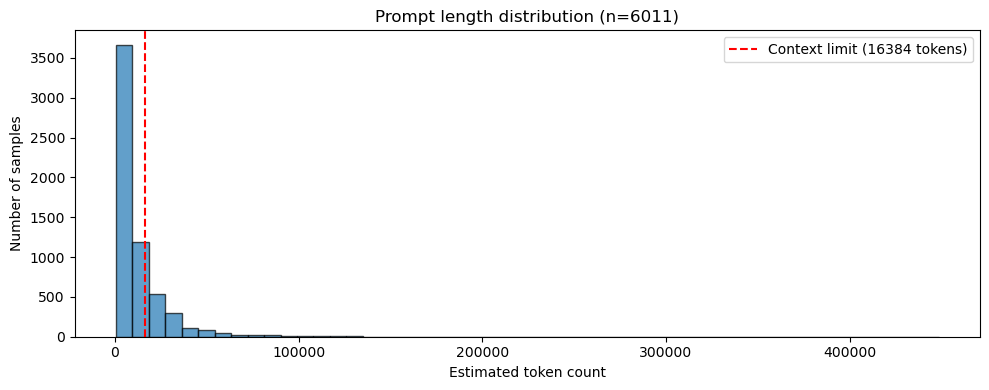


Within context budget: 4641/6011 (77.2%)
Exceeding budget:     1370/6011 (22.8%)

Median length: 6722 tokens
95th percentile: 38166 tokens


In [20]:
TARGET_CONTEXT = 16384

# Build prompts for a subset to measure lengths
N_SAMPLE = len(df_raw)
sample_rows = df_raw.head(N_SAMPLE).to_dict(orient="records")
result = pipeline.run(sample_rows)
prompt_lengths = [len(p) / 4 for p in result["prompts"]]

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.hist(prompt_lengths, bins=50, edgecolor="black", alpha=0.7)
ax.axvline(TARGET_CONTEXT, color="red", linestyle="--", label=f"Context limit ({TARGET_CONTEXT} tokens)")
ax.set_xlabel("Estimated token count")
ax.set_ylabel("Number of samples")
ax.set_title(f"Prompt length distribution (n={N_SAMPLE})")
ax.legend()
plt.tight_layout()
plt.show()

within_budget = sum(1 for l in prompt_lengths if l <= TARGET_CONTEXT)
print(f"\nWithin context budget: {within_budget}/{N_SAMPLE} ({100*within_budget/N_SAMPLE:.1f}%)")
print(f"Exceeding budget:     {N_SAMPLE - within_budget}/{N_SAMPLE} ({100*(N_SAMPLE - within_budget)/N_SAMPLE:.1f}%)")
print(f"\nMedian length: {sorted(prompt_lengths)[len(prompt_lengths)//2]:.0f} tokens")
print(f"95th percentile: {sorted(prompt_lengths)[int(len(prompt_lengths)*0.95)]:.0f} tokens")

The distribution confirms that our 16,384-token context budget is a practical choice: **77.2%** of all samples already fit within this limit after applying the compression heuristics from Section 3 (file-tree truncation, function-body collapsing, docstring stripping, dependency selection). The median prompt length is ~6.7K tokens — well under the budget — meaning the typical sample leaves substantial room for the model's output.

## 7. Final Label Definition

The cleaned dataset contains per-comment categories, but the model is trained as a **binary detector**: does this file contain an issue that warrants a review comment? To build a sufficiently large and diverse positive class while keeping label quality high, we combine samples from several categories with different inclusion rates.

### Positive examples (label = 1)

A sample is labeled positive if at least one of its comments belongs to an included category. The composition of the positive class:

| Category | Inclusion rate | Rationale |
|---|---|---|
| `blocking_issue` | **100 %** | Core target — correctness bugs, security flaws, crashes. Every such example is valuable. |
| `performance` | **100 %** | Efficiency problems that can affect production behavior. Relatively rare (~100 comments), so all are included. |
| `best_practice` | **50 %** (random sample) | The largest category (~2 100 comments). Many describe concrete, actionable issues, but others are vague architectural suggestions. Including half adds volume while limiting noise. |

The positive set is anchored in clear-cut defects (`blocking_issue` + `performance`) and augmented with a controlled share of design-level feedback (`best_practice`). The 50 % sampling rate for `best_practice` is a deliberate trade-off: including all of them would risk diluting label precision, while excluding them entirely would leave the positive class too small for effective training.

### Negative examples (label = 0)

A sample is considered a clean negative if:
- It received **no human comments**, and
- The LLM judge validated it as containing **no blocking issue** (`has_blocking_issues = False`).

### Excluded from training

The following categories are excluded from the initial training set to avoid noisy supervision:
- `style`, `documentation`, `nitpick`, `praise` — these do not indicate code defects.
- `question`, `other` — ambiguous intent; may or may not relate to actual issues.

These excluded samples are preserved in the dataset for potential use as **hard negatives** in later training iterations or for analytical purposes.

### Why prioritize precision?

A code reviewer that produces too many false positives (flagging correct code) will quickly lose developer trust. By anchoring the positive class in `blocking_issue` and `performance` and carefully sampling from `best_practice`, we aim for a model with high precision while still having enough training data to learn meaningful patterns.

In [22]:
import numpy as np

ALWAYS_POSITIVE = {"blocking_issue", "performance"}
BEST_PRACTICE_SAMPLE_RATE = 0.5

def _has_category(categories_str, cats):
    if not categories_str or str(categories_str).startswith("Too long"):
        return False
    return any(c in str(categories_str) for c in cats)

def is_clean_negative(row):
    return row.get("has_blocking_issues", "") == "False"

mask_always_pos = df_cleaned["comment_categories"].apply(
    lambda x: _has_category(x, ALWAYS_POSITIVE)
)

mask_bp_only = (
    df_cleaned["comment_categories"].apply(lambda x: _has_category(x, {"best_practice"}))
    & ~mask_always_pos
)

np.random.seed(42)
bp_indices = df_cleaned.index[mask_bp_only]
bp_sampled = np.random.choice(bp_indices, size=int(len(bp_indices) * BEST_PRACTICE_SAMPLE_RATE), replace=False)

mask_positive = mask_always_pos | df_cleaned.index.isin(bp_sampled)
mask_negative = df_cleaned.apply(is_clean_negative, axis=1)

n_pos = mask_positive.sum()
n_neg = mask_negative.sum()
n_excluded = len(df_cleaned) - n_pos - n_neg

print(f"Positive examples:")
print(f"  blocking_issue | performance (100%): {mask_always_pos.sum():,}")
print(f"  best_practice (50% sample):          {len(bp_sampled):,} / {len(bp_indices):,}")
print(f"  total positive:                      {n_pos:,}")
print(f"Negative examples (validated clean):   {n_neg:,}")
print(f"Excluded from training:                {n_excluded:,}")

Positive examples:
  blocking_issue | performance (100%): 525
  best_practice (50% sample):          542 / 1,084
  total positive:                      1,067
Negative examples (validated clean):   1,897
Excluded from training:                3,047


## 8. Train / Validation / Test Split

### Step 1 — Carve out a held-out test set

Before any train/val splitting, we select **100 pull requests that contain at least one `blocking_issue` file** and remove them entirely from the training pool. By restricting the candidate pool to PRs with confirmed defects, we guarantee that every test PR contributes at least one positive example, yielding a substantially larger and more reliable test set than random PR selection would. Only a strict subset of each PR's files is kept:

| Subset | Condition | Purpose |
|---|---|---|
| Positive | File has at least one comment classified as `blocking_issue` | Ground-truth defects — the exact signal the model must detect. |
| Negative | File received **no** human comments **and** the LLM judge confirmed no blocking issue | Ground-truth clean files — verified absence of defects. |

All other files from the 100 test PRs (e.g. those with only `style`, `nitpick`, or `best_practice` comments) are **discarded** from the test set. This gives us a clean, unambiguous binary evaluation benchmark: every test positive is a confirmed bug, every test negative is a confirmed clean file.

### Step 2 — Remove test repositories from the training pool

All repositories that appear in the 100 test PRs are **completely excluded** from the training pool. This means every sample (from any PR) belonging to a test repository is dropped before the train/val split. Repository-level isolation prevents the model from learning repository-specific patterns (coding style, naming conventions, typical PR structure) that could inflate test metrics.

### Step 3 — Train / Validation split from remaining PRs

The remaining PRs (after removing all test-repository samples) are split into **train** and **validation** sets:

1. **No PR leakage.** All files from the same pull request go to the same split. This prevents the model from memorizing shared PR context.

2. **Same label distribution.** Both train and val use the same positive-class composition defined in Section 7 (`blocking_issue` 100 %, `performance` 100 %, `best_practice` 50 %). The negative class consists of LLM-validated clean files.

3. **Stratification.** The split is stratified by label to maintain consistent class balance.

4. **Split ratio.** 80 / 20 train / validation.

### Why PR-level and repository-level splitting matters

A single pull request often modifies several files that share the same context (PR description, repository state, author patterns). If some files from a PR appear in training and others in validation, the model could exploit shared context rather than learning to identify code issues. PR-level splitting eliminates this source of optimistic bias.

Going further, different PRs within the same repository share coding conventions, project structure, and dependency patterns. If the model trains on PR A from `repo X` and is then tested on PR B from the same `repo X`, it may leverage repository familiarity rather than genuine code-understanding ability. By holding out entire repositories at the test boundary, we ensure the test metric measures generalization to **unseen projects**.

### Why a separate test distribution?

Train and val include softer categories (`performance`, `best_practice`) to give the model more training signal. The test set, by contrast, is restricted to the hardest and most unambiguous labels (`blocking_issue` only for positives). This ensures the final metric reflects real-world precision on true defects, not on stylistic or architectural suggestions.

In [31]:
df_labeled = df_cleaned[mask_positive | mask_negative].copy()
df_labeled["label"] = mask_positive[mask_positive | mask_negative].astype(int)
print(f"Labeled dataset: {len(df_labeled):,} samples  "
      f"(pos={df_labeled['label'].sum():,}, neg={(df_labeled['label']==0).sum():,})")

# ----- Step 1: carve out test PRs (only PRs that contain blocking_issue) -----
pr_keys = df_labeled["repo"] + "/" + df_labeled["pr_number"].astype(str)

has_blocking = df_labeled["comment_categories"].apply(
    lambda x: "blocking_issue" in str(x) if x else False
)
prs_with_blocking = set(pr_keys[has_blocking].unique())
print(f"PRs containing at least one blocking_issue: {len(prs_with_blocking)}")

rng = np.random.RandomState(42)
n_test_prs = min(100, len(prs_with_blocking))
test_prs = set(rng.choice(sorted(prs_with_blocking), size=n_test_prs, replace=False))

df_test_pool = df_labeled[pr_keys.isin(test_prs)]

is_blocking_test = df_test_pool["comment_categories"].apply(
    lambda x: "blocking_issue" in str(x) if x else False
)
is_clean_neg = df_test_pool["has_blocking_issues"].astype(str) == "False"

df_test = df_test_pool[is_blocking_test | is_clean_neg].copy()
df_test["label"] = is_blocking_test[is_blocking_test | is_clean_neg].astype(int)

print(f"\nStep 1 — Test set: {len(df_test):,} samples from {len(test_prs)} PRs  "
      f"(pos={df_test['label'].sum():,}, neg={(df_test['label']==0).sum():,})")

# ----- Step 2: remove all test repositories from training pool -----
test_repos = set(df_test["repo"].unique())
df_train_pool = df_labeled[
    ~pr_keys.isin(test_prs) & ~df_labeled["repo"].isin(test_repos)
]
print(f"Step 2 — After repo holdout: {len(df_train_pool):,} samples  "
      f"(removed {len(test_repos)} repos)")

# ----- Step 3: train / val from remaining PRs -----
from sklearn.model_selection import GroupShuffleSplit

tv_pr_keys = df_train_pool["repo"] + "/" + df_train_pool["pr_number"].astype(str)
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(splitter.split(df_train_pool, groups=tv_pr_keys))

df_train = df_train_pool.iloc[train_idx].copy()
df_val   = df_train_pool.iloc[val_idx].copy()

print(f"Step 3 — Train: {len(df_train):,}  (pos={df_train['label'].sum():,}, "
      f"neg={(df_train['label']==0).sum():,})")
print(f"         Val:   {len(df_val):,}  (pos={df_val['label'].sum():,}, "
      f"neg={(df_val['label']==0).sum():,})")
print(f"         Test:  {len(df_test):,}  (pos={df_test['label'].sum():,}, "
      f"neg={(df_test['label']==0).sum():,})")

Labeled dataset: 2,964 samples  (pos=1,067, neg=1,897)
PRs containing at least one blocking_issue: 367

Step 1 — Test set: 292 samples from 100 PRs  (pos=128, neg=164)
Step 2 — After repo holdout: 2,449 samples  (removed 96 repos)
Step 3 — Train: 1,913  (pos=687, neg=1,226)
         Val:   536  (pos=162, neg=374)
         Test:  292  (pos=128, neg=164)


In [32]:
train_prs = set(df_train["repo"] + "/" + df_train["pr_number"].astype(str))
val_prs   = set(df_val["repo"]   + "/" + df_val["pr_number"].astype(str))
test_prs_final = set(df_test["repo"] + "/" + df_test["pr_number"].astype(str))

train_repos = set(df_train["repo"])
val_repos   = set(df_val["repo"])
test_repos_final = set(df_test["repo"])

train_idx_set = set(df_train.index)
val_idx_set   = set(df_val.index)
test_idx_set  = set(df_test.index)

checks = {
    "No PR overlap (train ∩ val)":       len(train_prs & val_prs) == 0,
    "No PR overlap (train ∩ test)":      len(train_prs & test_prs_final) == 0,
    "No PR overlap (val ∩ test)":        len(val_prs & test_prs_final) == 0,
    "No repo overlap (train ∩ test)":    len(train_repos & test_repos_final) == 0,
    "No repo overlap (val ∩ test)":      len(val_repos & test_repos_final) == 0,
    "No sample overlap (train ∩ val)":   len(train_idx_set & val_idx_set) == 0,
    "No sample overlap (train ∩ test)":  len(train_idx_set & test_idx_set) == 0,
    "No sample overlap (val ∩ test)":    len(val_idx_set & test_idx_set) == 0,
    "Test positives are blocking_issue only": all(
        "blocking_issue" in str(c)
        for c in df_test[df_test["label"] == 1]["comment_categories"]
    ),
    "Test negatives are validated clean": all(
        str(v) == "False"
        for v in df_test[df_test["label"] == 0]["has_blocking_issues"]
    ),
}

all_ok = True
for name, passed in checks.items():
    status = "PASS" if passed else "FAIL"
    if not passed:
        all_ok = False
    print(f"  [{status}] {name}")

print(f"\n{'All leakage checks passed.' if all_ok else 'SOME CHECKS FAILED — review the split logic.'}")

  [PASS] No PR overlap (train ∩ val)
  [PASS] No PR overlap (train ∩ test)
  [PASS] No PR overlap (val ∩ test)
  [PASS] No repo overlap (train ∩ test)
  [PASS] No repo overlap (val ∩ test)
  [PASS] No sample overlap (train ∩ val)
  [PASS] No sample overlap (train ∩ test)
  [PASS] No sample overlap (val ∩ test)
  [PASS] Test positives are blocking_issue only
  [PASS] Test negatives are validated clean

All leakage checks passed.


All 10 integrity checks pass, confirming that the split is free of data leakage at every level:

- **PR-level isolation**: no pull request is shared between any two splits, preventing the model from exploiting shared PR context (description, commit message, co-changed files).
- **Repository-level holdout**: test repositories are completely absent from both training and validation, ensuring the test metric reflects generalization to **unseen projects** rather than memorized coding conventions.
- **Label integrity**: every test positive is a confirmed `blocking_issue`, and every test negative is a file validated as clean by the LLM judge — giving us an unambiguous binary benchmark.

| Split | Samples | Positives | Negatives | Pos % |
|-------|--------:|----------:|----------:|------:|
| Train | 1,913 | 687 | 1,226 | 35.9% |
| Val | 536 | 162 | 374 | 30.2% |
| Test | 292 | 128 | 164 | 43.8% |

The class balance is consistent across train and val (~30–36% positive). The test set is intentionally enriched with positives (43.8%) because it is drawn exclusively from PRs that contain blocking issues, which naturally shifts the ratio. This is acceptable since test metrics (precision, recall, F1) are computed per-class and do not require a representative class prior.

## 9. Export Format

Final samples are exported in **JSONL** format (one JSON object per line), suitable for direct consumption by the training script. We deliberately include more context than the model strictly needs — raw fields enable offline re-processing (e.g. re-building prompts with different compression settings) without re-querying the GitHub API.

Each exported example contains:

| Field | Description |
|---|---|
| **Training fields** | |
| `prompt` | Fully assembled reviewer prompt (repository metadata + PR metadata + patched file + dependencies + file tree) |
| `target` | Expected model output: `{"issues": [{"line_range": {"start": ..., "end": ...}, "comment": "..."}]}` for positives, `{"issues": []}` for negatives |
| `label` | Binary label: `1` if the file contains a blocking issue, `0` otherwise |
| **Raw context (for re-processing)** | |
| `patched_content` | Original patched file content with diff markers (`+`/`-`) before compression |
| `outgoing_dependencies` | Files imported by the changed file (list of `{path, patched_content}`) |
| `incoming_dependencies` | Files that import from the changed file (list of `{path, patched_content}`) |
| `metadata_files` | Repository metadata files — README, CONTRIBUTING, setup.py, etc. |
| `file_tree` | Full repository file tree (before truncation) |
| `comments` | Raw human review comments with line ranges |
| **PR / repo metadata** | |
| `repo` | Repository identifier (`owner/name`) |
| `pr_number` | Pull request number |
| `pr_title` | Pull request title |
| `pr_body` | Pull request description |
| `path` | Changed file path within the repository |
| `commit_sha` | Commit SHA for traceability |
| `repo_star_count` | GitHub star count at collection time |
| **Label provenance** | |
| `comment_categories` | LLM-assigned categories for each comment (for analysis) |
| `has_blocking_issues` | LLM judge validation result for no-comment files |
| `llm_raw_response` | Unparsed LLM judge response (for debugging) |
| `split` | Dataset split: `train`, `val`, or `test` |

In [ ]:
import json, ast

EXPORT_DIR = PROJECT_ROOT / "data"
EXPORT_DIR.mkdir(exist_ok=True)

RAW_FIELDS = [
    "patched_content", "outgoing_dependencies", "incoming_dependencies",
    "metadata_files", "file_tree", "comments",
]
META_FIELDS = [
    "repo", "pr_number", "pr_title", "pr_body", "path",
    "commit_sha", "repo_star_count",
]
LABEL_FIELDS = ["comment_categories", "has_blocking_issues", "llm_raw_response"]


def _serialize(val):
    if isinstance(val, (np.integer,)):
        return int(val)
    if isinstance(val, (np.floating,)):
        return float(val)
    if isinstance(val, np.ndarray):
        return val.tolist()
    if pd.isna(val):
        return None
    return val


def _parse_comments_raw(val):
    if val is None or (isinstance(val, float) and pd.isna(val)):
        return []
    if isinstance(val, str):
        try:
            val = ast.literal_eval(val)
        except (ValueError, SyntaxError):
            try:
                val = json.loads(val)
            except json.JSONDecodeError:
                return []
    if isinstance(val, np.ndarray):
        val = val.tolist()
    if isinstance(val, list):
        return val
    return []


def _build_target(comments_raw, label):
    """Build model target string matching the reviewer prompt output format."""
    if label == 0:
        return json.dumps({"issues": []}, ensure_ascii=False)

    comments = _parse_comments_raw(comments_raw)
    issues = []
    for c in comments:
        start = c.get("annotated_start_line")
        end = c.get("annotated_end_line")
        body = c.get("body", "")
        if start is None or end is None or not body:
            continue
        issues.append({
            "line_range": {"start": int(start), "end": int(end)},
            "comment": body.strip(),
        })
    return json.dumps({"issues": issues}, ensure_ascii=False)


def export_jsonl(df, split_name, pipeline):
    rows = df.reset_index(drop=True)
    result = pipeline.run(rows.to_dict(orient="records"))
    output_path = EXPORT_DIR / f"{split_name}.jsonl"

    with open(output_path, "w", encoding="utf-8") as f:
        for i in range(len(rows)):
            row = rows.iloc[i]
            record = {
                "prompt": result["prompts"][i],
                "target": _build_target(row.get("comments"), int(row["label"])),
                "label": int(row["label"]),
                "split": split_name,
            }
            for col in RAW_FIELDS + META_FIELDS + LABEL_FIELDS:
                if col in row.index:
                    record[col] = _serialize(row[col])
            f.write(json.dumps(record, ensure_ascii=False) + "\n")

    print(f"  {split_name:5s}: {len(rows):,} samples -> {output_path}")


print("Exporting splits...")
export_jsonl(df_train, "train", pipeline)
export_jsonl(df_val,   "val",   pipeline)
export_jsonl(df_test,  "test",  pipeline)
print("Done.")

## 10. Conclusion

This notebook documents the data preparation pipeline for the Automated Pull Request Reviewer project. The pipeline transforms noisy, real-world pull request review data into a clean, structured dataset with well-defined binary labels.

**Key steps summarized:**

1. Raw review events were ingested from GH Archive and enriched with full patches, base file content, and review thread metadata via the GitHub API.
2. Samples were organized at the file level: one changed Python file per sample, with associated context (dependencies, metadata, repository structure).
3. Human review comments were classified into a nine-category taxonomy using an LLM-as-a-judge pipeline, and uncommented files were validated for the absence of blocking issues.
4. Final labels were defined conservatively: only clear blocking issues and performance problems are treated as positives; validated clean files serve as negatives.
5. Context compression heuristics (docstring stripping, function body collapsing, dependency selection) ensure that prompts fit within the model's 16,384-token context window.
6. The train/validation split is performed at the PR level to prevent data leakage.

The result is a dataset that prioritizes **label precision** over coverage, reflecting the design philosophy that a code reviewer must be trustworthy above all else.